In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import glob
import os
import re
import matplotlib 
import matplotlib as mpl
from pathlib import Path

In [8]:
driver = "vGAT"
responder = "eOPN3_ATR"

homecomp = "D:"
base_path = "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\eOPN3 manuscript\\Data compilation\\Trumelan\\2. Processed\\"  
specifiedpath = homecomp + base_path

bin_size = 0.5  # seconds for heatmap resampling
framerate = 10  # Hz
illum_start = 60  # illumination start (seconds)
maxtime = 3600
specifictime = 600  # for shorter time plots (seconds)

#'ActivityLevel' or 'Speed'
metric_to_plot = 'ActivityLevel'

## Stacked by Illumination Duration

In [9]:
duration_files = {
    '0s': specifiedpath + driver + " x " + responder + "_0s",
    '5s': specifiedpath + driver + " x " + responder + "_5s",
    '30s': specifiedpath + driver + " x " + responder + "_30s",
    '60s': specifiedpath + driver + " x " + responder + "_60s",
}


duration_plot_title = driver + " > " + responder + " - Illumination Duration"

In [10]:
duration_data = {}

for label, filepath in duration_files.items():
    df = pd.read_csv(filepath + "_max" + str(maxtime) + "s.csv").set_index('Time (s)')
    df = df.iloc[0:(specifictime*2), :]  # trim to specifictime
    duration_data[label] = df.filter(regex="^" + metric_to_plot).T.reset_index(drop=True)

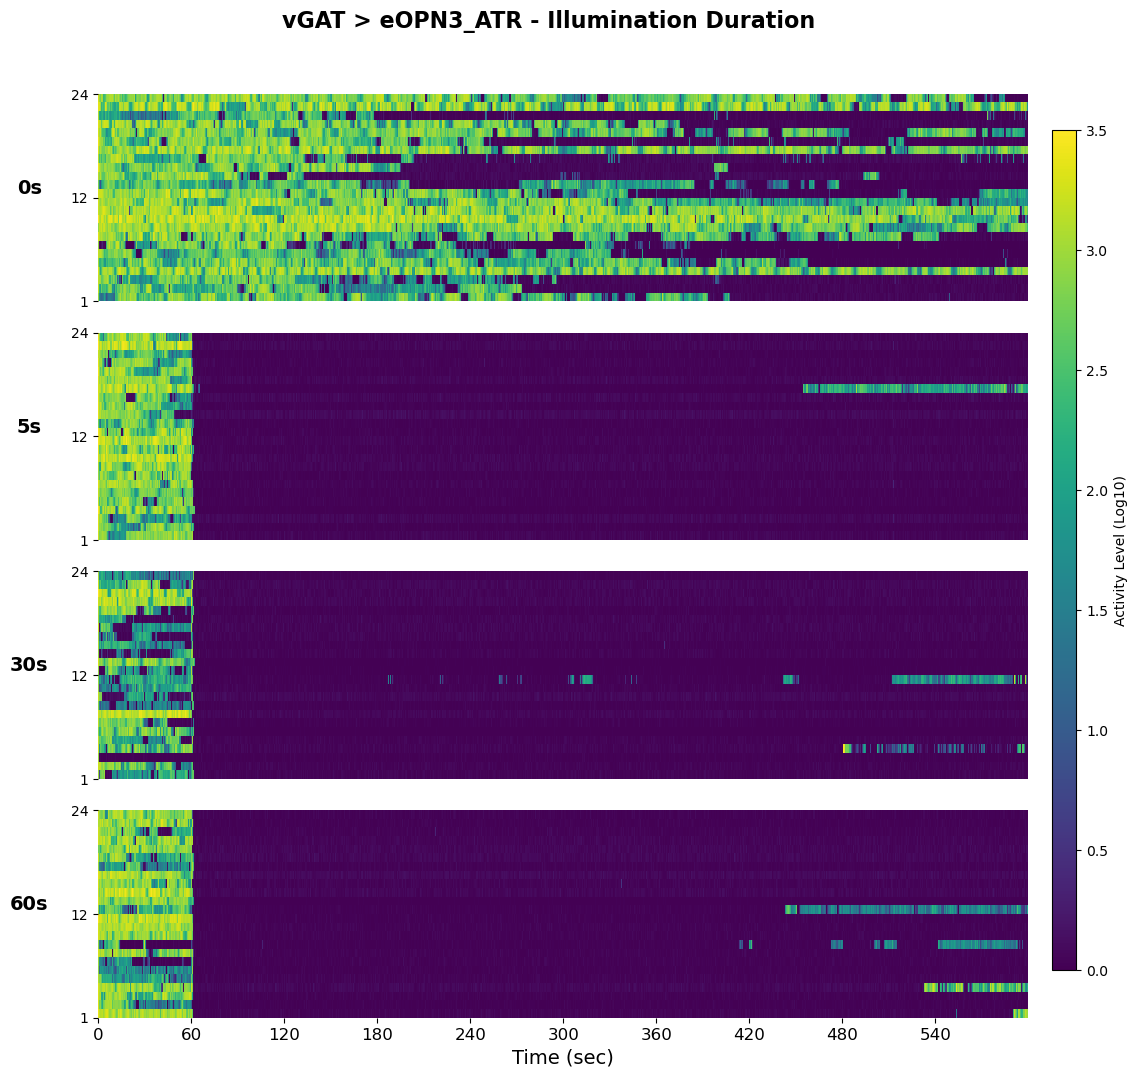

In [11]:
num_conditions = len(duration_data)
fig, axes = plt.subplots(num_conditions, 1, figsize=(12, 3*num_conditions), sharex=True)
plt.subplots_adjust(hspace=0.15)

if metric_to_plot == "ActivityLevel":
    scalebar_label = "Activity Level (Log10)"
elif metric_to_plot == "Speed":
    scalebar_label = "Speed (mm/s)"

for idx, (label, data) in enumerate(duration_data.items()):
    ax = axes[idx]
    num_flies = data.shape[0]
    
    hm = sns.heatmap(data, cmap="viridis", cbar=False, xticklabels=False, yticklabels=False, 
                     vmin=0, vmax=3.5, ax=ax)
    quadmesh = ax.collections[0]
    quadmesh.set_rasterized(True)
    quadmesh.set_edgecolor('face')
    quadmesh.set_linewidth(0)
    
    ax.set_ylabel(label, rotation=0, labelpad=30, fontsize=14, weight='bold')
    ax.set_yticks([0, num_flies//2, num_flies])
    ticklabels = [num_flies, (num_flies+1)//2, 1]
    ax.set_yticklabels(ticklabels, fontsize=10)
    
    if idx < num_conditions - 1:
        ax.tick_params(axis='x', bottom=False)
        ax.set_xlabel('')
    ax.patch.set_facecolor('white')


last_data = list(duration_data.values())[-1]
tick_times = list(range(0, int(specifictime), int(specifictime/10)))
tick_positions = [list(last_data.columns).index(float(t)) for t in tick_times if float(t) in last_data.columns]
axes[-1].set_xticks(tick_positions)
axes[-1].set_xticklabels(tick_times, rotation=0, fontsize=12)
axes[-1].set_xlabel("Time (sec)", fontsize=14)


cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
sm = plt.cm.ScalarMappable(cmap="viridis", norm=plt.Normalize(vmin=0, vmax=3.5))
fig.colorbar(sm, cax=cbar_ax, label=scalebar_label)

fig.suptitle(duration_plot_title, weight="bold", fontsize=16, y=0.95)

mpl.rcParams['svg.fonttype'] = 'none'
fig.patch.set_facecolor('white')

# plt.savefig(homecomp + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\eOPN3 manuscript\\Data compilation\\Trumelan\\Trumelan images\\"
#             + "Stacked_duration_" + driver + "_" + responder + ".svg",
#             dpi=300, bbox_inches='tight', format='svg', facecolor='white', transparent=False)

## Stacked by Light Intensity

In [12]:
intensity_files = {
    'No Light': specifiedpath + driver + " x " + responder + "_0s",
    'Quarter': specifiedpath + driver + " x " + responder + "_quarter_5s",
    'Half': specifiedpath + driver + " x " + responder + "_half_5s",
    'Full': specifiedpath + driver + " x " + responder + "_5s",
}

intensity_plot_title = driver + " > " + responder + " - Light Intensity"

In [13]:
intensity_data = {}

for label, filepath in intensity_files.items():
    df = pd.read_csv(filepath + "_max" + str(maxtime) + "s.csv").set_index('Time (s)')
    df = df.iloc[0:(specifictime*2), :]  # trim to specifictime
    intensity_data[label] = df.filter(regex="^" + metric_to_plot).T.reset_index(drop=True)
    print(f"{label}: {intensity_data[label].shape[0]} flies")

No Light: 24 flies
Quarter: 43 flies
Half: 24 flies
Full: 24 flies


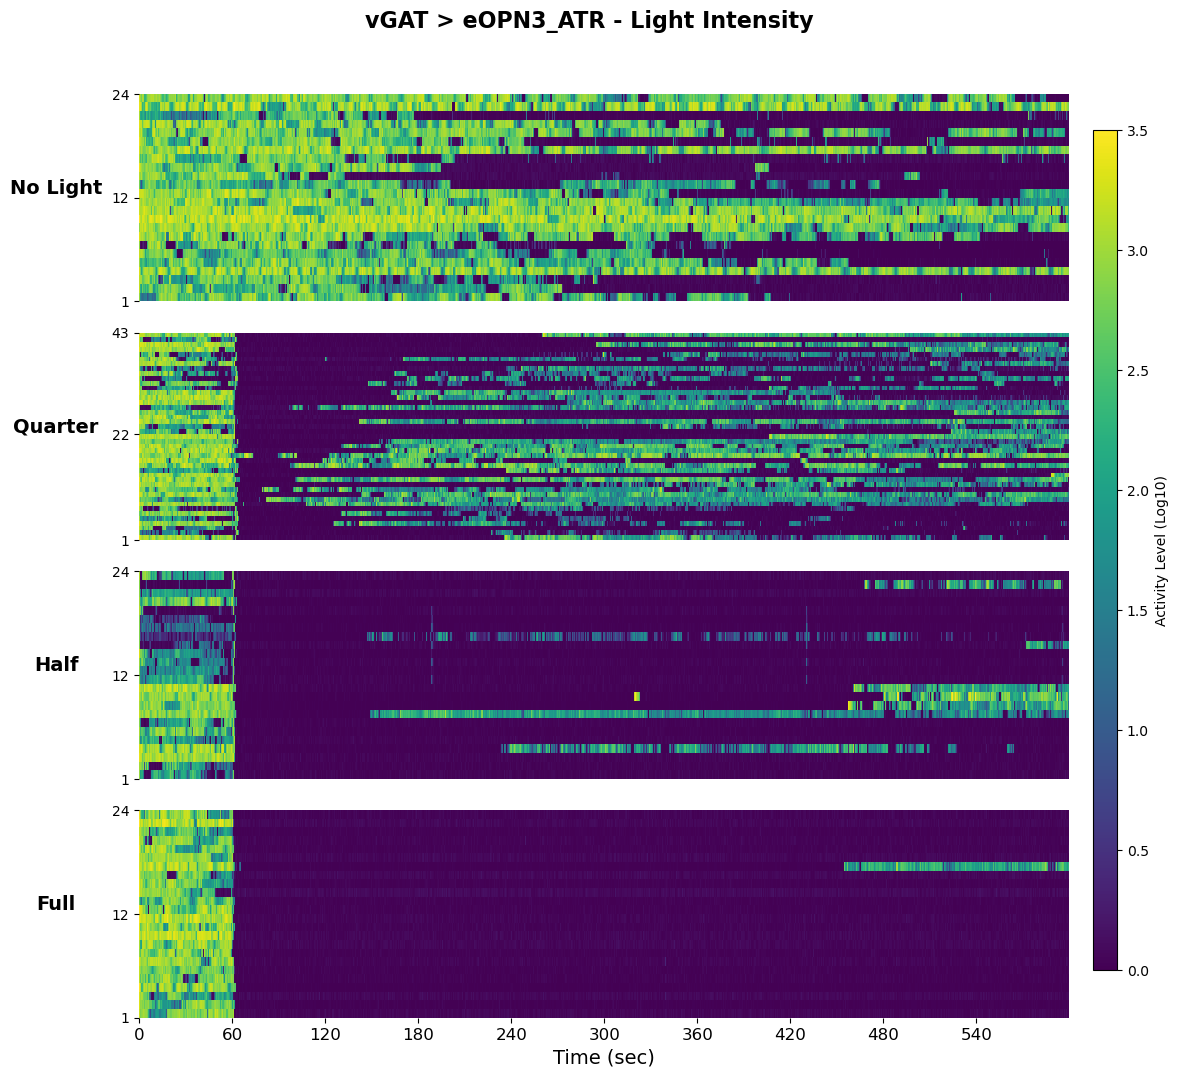

In [14]:
num_conditions = len(intensity_data)
fig, axes = plt.subplots(num_conditions, 1, figsize=(12, 3*num_conditions), sharex=True)
plt.subplots_adjust(hspace=0.15)

if metric_to_plot == "ActivityLevel":
    scalebar_label = "Activity Level (Log10)"
elif metric_to_plot == "Speed":
    scalebar_label = "Speed (mm/s)"

for idx, (label, data) in enumerate(intensity_data.items()):
    ax = axes[idx]
    num_flies = data.shape[0]
    
    hm = sns.heatmap(data, cmap="viridis", cbar=False, xticklabels=False, yticklabels=False, 
                     vmin=0, vmax=3.5, ax=ax)
    quadmesh = ax.collections[0]
    quadmesh.set_rasterized(True)
    quadmesh.set_edgecolor('face')
    quadmesh.set_linewidth(0)
    
    ax.set_ylabel(label, rotation=0, labelpad=40, fontsize=14, weight='bold')
    ax.set_yticks([0, num_flies//2, num_flies])
    ticklabels = [num_flies, (num_flies+1)//2, 1]
    ax.set_yticklabels(ticklabels, fontsize=10)
    
    if idx < num_conditions - 1:
        ax.tick_params(axis='x', bottom=False)
        ax.set_xlabel('')
    ax.patch.set_facecolor('white')

last_data = list(intensity_data.values())[-1]
tick_times = list(range(0, int(specifictime), int(specifictime/10)))
tick_positions = [list(last_data.columns).index(float(t)) for t in tick_times if float(t) in last_data.columns]
axes[-1].set_xticks(tick_positions)
axes[-1].set_xticklabels(tick_times, rotation=0, fontsize=12)
axes[-1].set_xlabel("Time (sec)", fontsize=14)

cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
sm = plt.cm.ScalarMappable(cmap="viridis", norm=plt.Normalize(vmin=0, vmax=3.5))
fig.colorbar(sm, cax=cbar_ax, label=scalebar_label)

fig.suptitle(intensity_plot_title, weight="bold", fontsize=16, y=0.95)

mpl.rcParams['svg.fonttype'] = 'none'
fig.patch.set_facecolor('white')

# plt.savefig(homecomp + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\eOPN3 manuscript\\Data compilation\\Trumelan\\Trumelan images\\"
#             + "Stacked_intensity_" + driver + "_" + responder + ".svg",
#             dpi=300, bbox_inches='tight', format='svg', facecolor='white', transparent=False)